**Titre :** Immo Predictor : Valorisation et Diagnostic Intelligent

In [352]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lespin/house-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-prices-dataset' dataset.
Path to dataset files: /kaggle/input/house-prices-dataset


In [353]:
# lister tous les fichiers et dossiers
!ls {path}

data_description.txt  sample_submission.csv  test.csv  train.csv


In [354]:
# Importation du bibliothèque pandas
import pandas as pd

In [355]:
# chargé le fichier train
df = pd.read_csv(path+"/train.csv")
df


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


 **Partie 1 :** Régression

**1. Analyse Exploratoire des Données (EDA):**

In [356]:
# Affichage de tous les variables
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [357]:
# Sélecltion des variables de la régression pour le train
features_reg = [
    "GrLivArea", "TotalBsmtSF", "LotArea",
    "BedroomAbvGr", "FullBath", "TotRmsAbvGrd",
    "OverallQual", "OverallCond", "YearBuilt",
    "YearRemodAdd", "Neighborhood",
    "GarageCars", "GarageArea",
    "PoolArea", "Fireplaces"
]

df_reg = df[features_reg + ["SalePrice"]]
df_reg

,GrLivArea,TotalBsmtSF,LotArea,BedroomAbvGr,FullBath,TotRmsAbvGrd,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Neighborhood,GarageCars,GarageArea,PoolArea,Fireplaces,SalePrice
0,1710,856,8450,3,2,8,7,5,2003,2003,CollgCr,2,548,0,0,208500
1,1262,1262,9600,3,2,6,6,8,1976,1976,Veenker,2,460,0,1,181500
2,1786,920,11250,3,2,6,7,5,2001,2002,CollgCr,2,608,0,1,223500
3,1717,756,9550,3,1,7,7,5,1915,1970,Crawfor,3,642,0,1,140000
4,2198,1145,14260,4,2,9,8,5,2000,2000,NoRidge,3,836,0,1,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,953,7917,3,2,7,6,5,1999,2000,Gilbert,2,460,0,1,175000
1456,2073,1542,13175,3,2,7,6,6,1978,1988,NWAmes,2,500,0,2,210000
1457,2340,1152,9042,4,2,9,7,9,1941,2006,Crawfor,1,252,0,2,266500
1458,1078,1078,9717,2,1,5,5,6,1950,1996,NAmes,1,240,0,0,142125


In [358]:
# Dimension
df_reg.shape

(1460, 16)

In [359]:
# détails
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   GrLivArea     1460 non-null   int64 
 1   TotalBsmtSF   1460 non-null   int64 
 2   LotArea       1460 non-null   int64 
 3   BedroomAbvGr  1460 non-null   int64 
 4   FullBath      1460 non-null   int64 
 5   TotRmsAbvGrd  1460 non-null   int64 
 6   OverallQual   1460 non-null   int64 
 7   OverallCond   1460 non-null   int64 
 8   YearBuilt     1460 non-null   int64 
 9   YearRemodAdd  1460 non-null   int64 
 10  Neighborhood  1460 non-null   object
 11  GarageCars    1460 non-null   int64 
 12  GarageArea    1460 non-null   int64 
 13  PoolArea      1460 non-null   int64 
 14  Fireplaces    1460 non-null   int64 
 15  SalePrice     1460 non-null   int64 
dtypes: int64(15), object(1)
memory usage: 182.6+ KB


In [360]:
df_reg.describe()

,GrLivArea,TotalBsmtSF,LotArea,BedroomAbvGr,FullBath,TotRmsAbvGrd,OverallQual,OverallCond,YearBuilt,YearRemodAdd,GarageCars,GarageArea,PoolArea,Fireplaces,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,1057.429452,10516.828082,2.866438,1.565068,6.517808,6.099315,5.575342,1971.267808,1984.865753,1.767123,472.980137,2.758904,0.613014,180921.195890
std,525.480383,438.705324,9981.264932,0.815778,0.550916,1.625393,1.382997,1.112799,30.202904,20.645407,0.747315,213.804841,40.177307,0.644666,79442.502883
min,334.000000,0.000000,1300.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,1129.500000,795.750000,7553.500000,2.000000,1.000000,5.000000,5.000000,5.000000,1954.000000,1967.000000,1.000000,334.500000,0.000000,0.000000,129975.000000
50%,1464.000000,991.500000,9478.500000,3.000000,2.000000,6.000000,6.000000,5.000000,1973.000000,1994.000000,2.000000,480.000000,0.000000,1.000000,163000.000000
75%,1776.750000,1298.250000,11601.500000,3.000000,2.000000,7.000000,7.000000,6.000000,2000.000000,2004.000000,2.000000,576.000000,0.000000,1.000000,214000.000000
max,5642.000000,6110.000000,215245.000000,8.000000,3.000000,14.000000,10.000000,9.000000,2010.000000,2010.000000,4.000000,1418.000000,738.000000,3.000000,755000.000000


In [361]:
# Le nombre de lignes dupliquées
df_reg.duplicated().sum()

np.int64(0)

In [362]:
# Le nombre de données manquantes
df_reg.isna().sum().sum()

np.int64(0)

In [363]:
# Le nombre d'occurence pour la variable catégorielle
df_reg["Neighborhood"].value_counts()

,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


In [364]:
# Importation de seaborn et matplotlib pour la visualisation
import seaborn as sns
import matplotlib.pyplot as plt

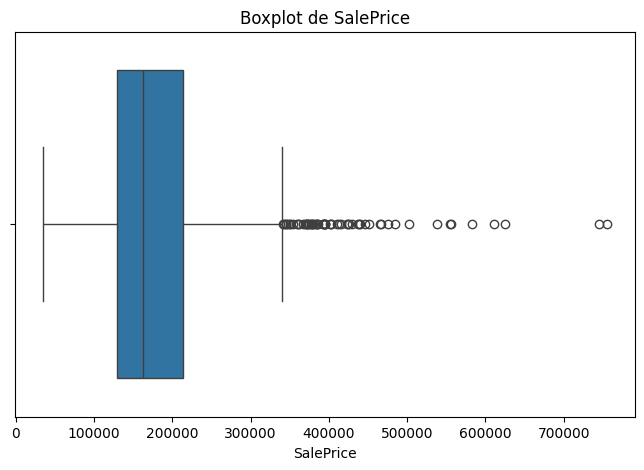

In [365]:
# Vérifions la nature de la distribution et s'il y'a des valeurs abérrantes
plt.figure(figsize=(8,5))
sns.boxplot(x=df_reg["SalePrice"])
plt.title("Boxplot de SalePrice")
plt.show()

- L’analyse exploratoire de la variable SalePrice à l’aide d’un boxplot montre une distribution légèrement asymétrique ainsi que la présence de valeurs aberrantes (outliers), ce qui peut influencer les modèles de régression.

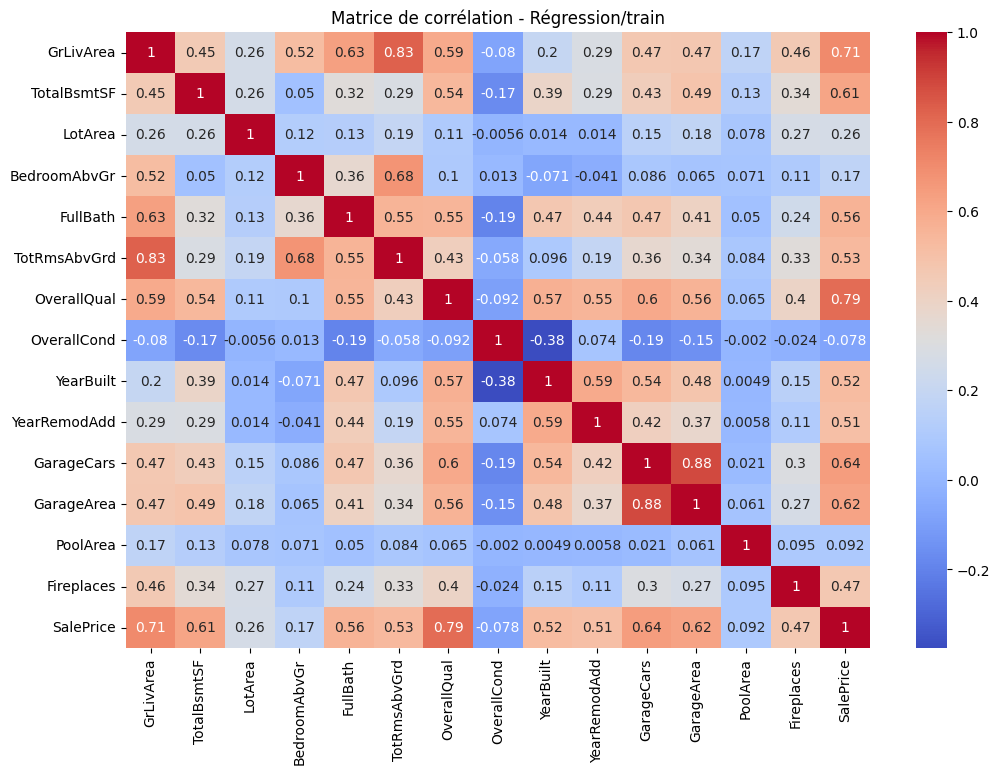

In [366]:
# matrice de corrélation
plt.figure(figsize=(12,8))
sns.heatmap(df_reg.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Matrice de corrélation - Régression/train")
plt.show()

**2. Pré-traitement**

**a. Gestion des valeurs manquantes et encodage des variables
catégorielles**

train.csv

- Il n'y a pas de **valeurs manquantes** à traiter pour le train.

- Traitons les **valeurs abérrantes (outliers)** en utilisant IQR

In [367]:
def imputeOutliersIQR(data, factor=1.5):
    df = data.copy()
    for col in df.select_dtypes(include="number").columns: # colonnes numériques
        if not (-0.5 <= df[col].skew() <= 0.5): # colonnes asymètriques
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            IQR = q3 - q1
            lowerBound = q1 - factor * IQR
            upperBound = q3 + factor * IQR
            df[col] = df[col].clip(lower=lowerBound, upper=upperBound)
    return df

In [368]:
# Appliquer la fonction
df_reg_clean = imputeOutliersIQR(df_reg)

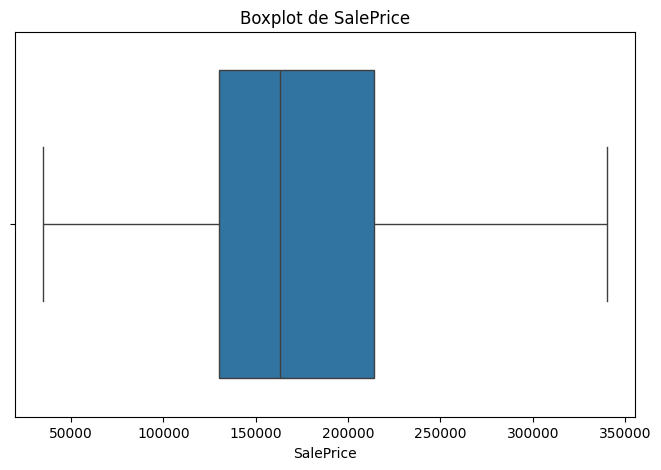

In [369]:
# Vérifions l'effet
plt.figure(figsize=(8,5))
sns.boxplot(x=df_reg_clean["SalePrice"])
plt.title("Boxplot de SalePrice")
plt.show()

In [370]:
# La variable cible
y_reg = df_reg_clean['SalePrice']

In [371]:
# Toutes les autres colonnes sont les features
x_reg = df_reg_clean.drop(columns=['SalePrice'])
x_reg

,GrLivArea,TotalBsmtSF,LotArea,BedroomAbvGr,FullBath,TotRmsAbvGrd,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Neighborhood,GarageCars,GarageArea,PoolArea,Fireplaces
0,1710.0,856,8450.0,3,2,8,7,5.0,2003,2003,CollgCr,2,548,0,0.0
1,1262.0,1262,9600.0,3,2,6,6,7.5,1976,1976,Veenker,2,460,0,1.0
2,1786.0,920,11250.0,3,2,6,7,5.0,2001,2002,CollgCr,2,608,0,1.0
3,1717.0,756,9550.0,3,1,7,7,5.0,1915,1970,Crawfor,3,642,0,1.0
4,2198.0,1145,14260.0,4,2,9,8,5.0,2000,2000,NoRidge,3,836,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647.0,953,7917.0,3,2,7,6,5.0,1999,2000,Gilbert,2,460,0,1.0
1456,2073.0,1542,13175.0,3,2,7,6,6.0,1978,1988,NWAmes,2,500,0,2.0
1457,2340.0,1152,9042.0,4,2,9,7,7.5,1941,2006,Crawfor,1,252,0,2.0
1458,1078.0,1078,9717.0,2,1,5,5,6.0,1950,1996,NAmes,1,240,0,0.0


- La variable Neighborhood est de type qualitative et nominal, on va utiliser OneHotEncoder pour l'encoder.

In [372]:
# Encodage de la variable Neighborhood
from sklearn.preprocessing import OneHotEncoder

In [373]:
# Séparer les variables
num_features = x_reg.select_dtypes(exclude="object").columns
cat_features = x_reg.select_dtypes(include="object").columns

In [374]:
# Encodage des variables catégorielles
encoder_reg = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
x_cat_df = pd.DataFrame(
    encoder_reg.fit_transform(x_reg[cat_features]),
    columns=encoder_reg.get_feature_names_out(cat_features),
    index=x_reg.index
)

In [375]:
# Récupérer les variables numériques
x_num_df = x_reg[num_features].reset_index(drop=True)

**Normalisation / Standardisation**

In [376]:
from sklearn.preprocessing import StandardScaler

In [377]:
# Standardisation
scaler_reg = StandardScaler()
x_num_scaled = pd.DataFrame(
    scaler_reg.fit_transform(x_reg[num_features]),
    columns=num_features,
    index=x_reg.index
)
x_num_scaled

,GrLivArea,TotalBsmtSF,LotArea,BedroomAbvGr,FullBath,TotRmsAbvGrd,OverallQual,OverallCond,YearBuilt,YearRemodAdd,GarageCars,GarageArea,PoolArea,Fireplaces
0,0.428636,-0.488321,-0.333244,0.163779,0.789741,0.981148,0.651479,-0.564161,1.053246,0.878668,0.311725,0.351000,0.0,-0.957043
1,-0.502349,0.532289,-0.013189,0.163779,0.789741,-0.316385,-0.071836,2.030907,0.156179,-0.429577,0.311725,-0.060731,0.0,0.608540
2,0.586571,-0.327437,0.446022,0.163779,0.789741,-0.316385,0.651479,-0.564161,0.986797,0.830215,0.311725,0.631726,0.0,0.608540
3,0.443182,-0.739702,-0.027104,0.163779,-1.026041,0.332382,0.651479,-0.564161,-1.870528,-0.720298,1.650307,0.790804,0.0,0.608540
4,1.442744,0.238172,1.283733,1.390023,0.789741,1.629914,1.374795,-0.564161,0.953572,0.733308,1.650307,1.698485,0.0,0.608540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.297716,-0.244481,-0.481583,0.163779,0.789741,0.332382,-0.071836,-0.564161,0.920347,0.733308,0.311725,-0.060731,0.0,0.608540
1456,1.182983,1.236157,0.981767,0.163779,0.789741,0.332382,-0.071836,0.473866,0.222628,0.151865,0.311725,0.126420,0.0,2.174122
1457,1.737833,0.255769,-0.168485,1.390023,0.789741,1.629914,0.651479,2.030907,-1.006686,1.024029,-1.026858,-1.033914,0.0,2.174122
1458,-0.884718,0.069746,0.019374,-1.062465,-1.026041,-0.965151,-0.795151,0.473866,-0.707663,0.539493,-1.026858,-1.090059,0.0,-0.957043


In [378]:
# Combiner les variables numériques et catégorielles encodées
x_reg_final = pd.concat([x_num_scaled, x_cat_df], axis=1)
x_reg_final.shape

(1460, 38)

**3. Modélisation :**

Decision Tree

In [379]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [449]:
# Séparation de la base en trai/test
x_train, x_test, y_train, y_test = train_test_split(
    x_reg_final, y_reg,
    test_size=0.3,
    random_state=42
)


In [381]:
# Créer le modèle
dtr = DecisionTreeRegressor(random_state=42)

In [382]:
# Entraîner le modèle
dtr.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [383]:
# Prédictions
y_pred_dtr = dtr.predict(x_test)
y_pred_dtr

array([139000. , 340037.5, 118000. , 210000. , 248900. ,  81000. ,
       219500. , 148500. ,  81000. ,  97500. , 174000. , 127500. ,
        80000. , 214000. , 193500. , 123500. , 191000. , 139000. ,
       118000. , 191000. , 172500. , 174000. , 200500. , 119750. ,
       179000. , 140000. , 184000. ,  80000. , 192000. , 196000. ,
       110000. , 280000. , 207500. , 110000. , 295493. , 174900. ,
        93000. , 199900. , 290000. , 127500. , 134900. , 233000. ,
       123000. , 340037.5, 132250. , 128000. , 100000. , 109900. ,
       340037.5, 143000. , 119500. , 110000. ,  90350. , 340037.5,
       140000. , 240000. , 210000. , 157000. , 142500. , 116000. ,
        60000. , 158000. , 325300. , 340037.5, 340037.5, 277000. ,
       108000. , 340037.5, 126000. , 168500. , 118964. , 125000. ,
       119000. ,  92900. , 340037.5, 176432. , 337000. , 260000. ,
       125000. , 127000. ,  94500. ,  83000. , 132250. ,  90350. ,
       130500. , 146500. , 252000. , 189000. , 134000. , 20014

Random Forest

In [451]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [385]:
# meilleur estimateur
parameters = {'n_estimators':[4,10,100,25,50,250,15]}

In [452]:
# Créer le modèle
rfr = RandomForestRegressor(random_state=42)
grid = GridSearchCV(rfr, parameters)

In [453]:
# Entraîner le modèle
grid.fit(x_train, y_train)

GridSearchCV(estimator=RandomForestRegressor(random_state=42),
             param_grid={'n_estimators': [4, 10, 100, 25, 50, 250, 15]})

In [454]:
import pickle

# Vérification avant sauvegarde
print("Type :", type(grid.best_estimator_))
print("Features :", grid.best_estimator_.feature_names_in_.tolist())

# Sauvegarde
with open('model_reg.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)
print("✅ model_reg.pkl sauvegardé !")

Type : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Features : ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath', 'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'GarageCars', 'GarageArea', 'PoolArea', 'Fireplaces', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']
✅ model_reg.pkl sauvegardé !


In [388]:
grid.best_estimator_

RandomForestRegressor(n_estimators=250, random_state=42)

In [389]:
# Prédictions
y_pred_rfr = grid.best_estimator_.predict(x_test)
y_pred_rfr

array([144399.4       , 312302.866     , 122730.3       , 173326.        ,
       278008.594     ,  79904.        , 212200.044     , 150205.708     ,
        80085.6       , 133408.94      , 156503.54      , 120784.        ,
        98010.8       , 218234.112     , 183053.2       , 129039.3       ,
       192727.944     , 134535.4       , 116620.        , 197444.244     ,
       179550.6       , 225613.592     , 174005.388     , 122990.48      ,
       190857.748     , 164672.928     , 179072.628     , 102472.948     ,
       181965.        , 195852.708     , 119957.244     , 243093.32      ,
       208278.62      , 113704.4       , 260498.844     , 146534.5       ,
       134024.564     , 203647.308     , 308316.974     , 110951.        ,
       125860.9       , 231207.392     , 117411.9       , 328194.768     ,
       135231.22      , 132768.08      , 113725.4       , 121850.84      ,
       339049.222     , 133710.424     , 117464.8       , 179463.328     ,
       119666.936     , 2

**Évaluation :**

Décision tree

In [390]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [391]:
# MAE
mae_dtr = mean_absolute_error(y_test, y_pred_dtr)
mae_dtr

21946.55821917808

In [392]:
# MSE
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
mse_dtr

987202775.8076484

In [393]:
# RMSE
import numpy as np
rmse_dtr = np.sqrt(mse_dtr)
print(rmse_dtr)

31419.783191607934


In [394]:
# R2
R2_dtr = r2_score(y_test, y_pred_dtr)
R2_dtr

0.7887553237695667

Random forest

In [395]:
# MAE
mae_rfr = mean_absolute_error(y_test, y_pred_rfr)
mae_rfr

14706.463072146118

In [396]:
# MSE
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
mse_rfr

433124227.5140414

In [397]:
# RMSE
import numpy as np
rmse_rfr = np.sqrt(mse_rfr)
print(rmse_rfr)

20811.63682928475


In [398]:
# R2
R2_rfr = r2_score(y_test, y_pred_rfr)
R2_rfr

0.9073187500572956

In [399]:
import pickle

# Sauvegarder les modèles
with open('model_reg.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)  # Random Forest Régression

In [400]:
with open('encoder_reg.pkl', 'wb') as f:
    pickle.dump(encoder_reg, f)

In [401]:
with open('scaler_reg.pkl', 'wb') as f:
    pickle.dump(scaler_reg, f)

In [402]:


# Vérifier les colonnes exactes attendues par le modèle de régression
print("Colonnes attendues par model_reg :", grid.best_estimator_.feature_names_in_.tolist())

Colonnes attendues par model_reg : ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath', 'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'GarageCars', 'GarageArea', 'PoolArea', 'Fireplaces', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']


 **Partie 2 :** Classification

**1. Analyse Exploratoire des Données (EDA):**

In [403]:
# Sélection des variables de la classification
features_clf = [
    "GrLivArea",
    "TotRmsAbvGrd",
    "OverallQual",
    "YearBuilt",
    "GarageCars",
    "Neighborhood",
    "HouseStyle",
    "BldgType"
]

df_clf = df[features_clf]
df_clf

,GrLivArea,TotRmsAbvGrd,OverallQual,YearBuilt,GarageCars,Neighborhood,HouseStyle,BldgType
0,1710,8,7,2003,2,CollgCr,2Story,1Fam
1,1262,6,6,1976,2,Veenker,1Story,1Fam
2,1786,6,7,2001,2,CollgCr,2Story,1Fam
3,1717,7,7,1915,3,Crawfor,2Story,1Fam
4,2198,9,8,2000,3,NoRidge,2Story,1Fam
...,...,...,...,...,...,...,...,...
1455,1647,7,6,1999,2,Gilbert,2Story,1Fam
1456,2073,7,6,1978,2,NWAmes,1Story,1Fam
1457,2340,9,7,1941,1,Crawfor,2Story,1Fam
1458,1078,5,5,1950,1,NAmes,1Story,1Fam


In [404]:
# Dimension
df_clf.shape

(1460, 8)

In [405]:
# détails
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   GrLivArea     1460 non-null   int64 
 1   TotRmsAbvGrd  1460 non-null   int64 
 2   OverallQual   1460 non-null   int64 
 3   YearBuilt     1460 non-null   int64 
 4   GarageCars    1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   HouseStyle    1460 non-null   object
 7   BldgType      1460 non-null   object
dtypes: int64(5), object(3)
memory usage: 91.4+ KB


In [406]:
# Le nombre de lignes dupliquées
df_clf.duplicated().sum()

np.int64(29)

In [407]:
# Le nombre de données manquantes
df_clf.isna().sum().sum()

np.int64(0)

In [408]:
# Le nombre d'occurence pour Neighborhood
df_reg["Neighborhood"].value_counts()

,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


In [409]:
# Le nombre d'occurence pour HouseStyle
df_clf["HouseStyle"].value_counts()

,count
HouseStyle,
1Story,726
2Story,445
1.5Fin,154
SLvl,65
SFoyer,37
1.5Unf,14
2.5Unf,11
2.5Fin,8


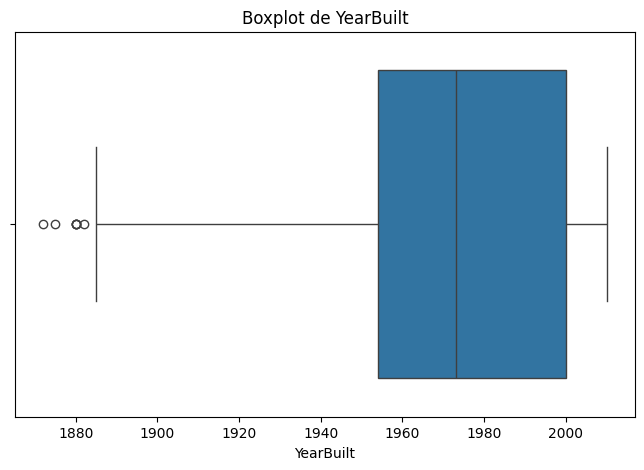

In [410]:
# Vérifions la nature de la distribution et s'il y'a des valeurs abérrantes
plt.figure(figsize=(8,5))
sns.boxplot(x=df_reg["YearBuilt"])
plt.title("Boxplot de YearBuilt")
plt.show()

- La distribution est asymétrie et comporte des valeurs abbérantes.

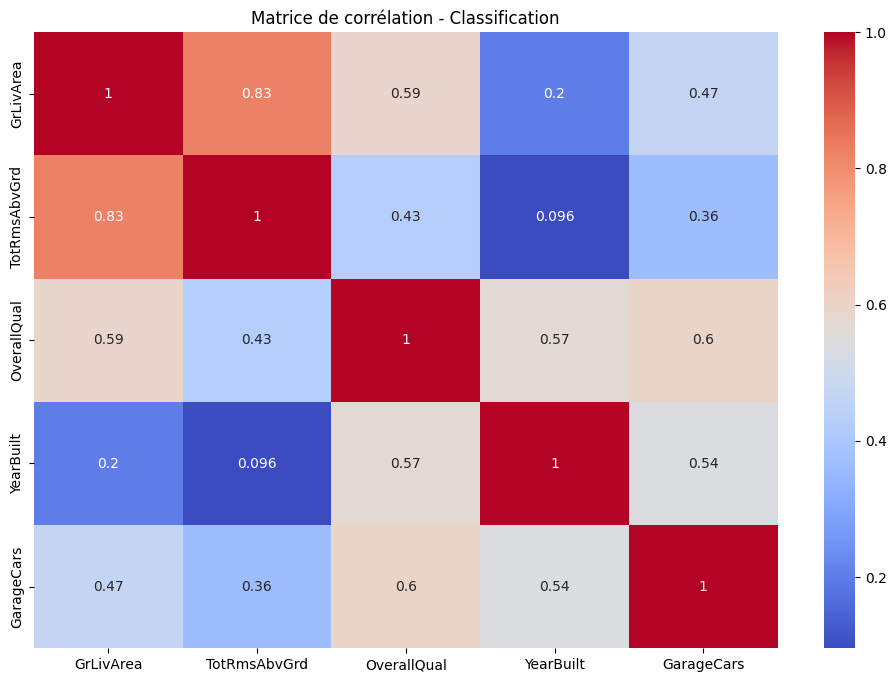

In [411]:
# matrice de corrélation
plt.figure(figsize=(12,8))
sns.heatmap(df_clf.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Matrice de corrélation - Classification")
plt.show()

**2. Pré-traitement**

**a. Gestion des valeurs manquantes Encodage des variables
catégorielles**

- Il y'a pas de données manquantes à traiter.

Il y'a 29 lignes dupliquées.

In [412]:
# Affichage des lignes dupliquées
df_clf[df_clf.duplicated(keep=False)].sort_values(by=features_clf)

,GrLivArea,TotRmsAbvGrd,OverallQual,YearBuilt,GarageCars,Neighborhood,HouseStyle,BldgType
274,816,5,5,1982,1,Mitchel,1Story,1Fam
1327,816,5,5,1982,1,Mitchel,1Story,1Fam
850,848,3,6,2003,2,CollgCr,1Story,TwnhsE
1422,848,3,6,2003,2,CollgCr,1Story,TwnhsE
203,848,3,6,2004,2,CollgCr,1Story,TwnhsE
690,848,3,6,2004,2,CollgCr,1Story,TwnhsE
721,848,3,6,2004,2,CollgCr,1Story,TwnhsE
1078,848,3,6,2004,2,CollgCr,1Story,TwnhsE
1441,848,3,6,2004,2,CollgCr,1Story,TwnhsE
593,848,4,6,2003,2,CollgCr,1Story,TwnhsE


- Là on peux supprimer les lignes dupliquées car elles identiques sur toutes les features et identiques sur la cible. (elles peuvent biaisées l'entrainement si on les garde)

In [413]:
# Suppression des lignes dupliquées
df_clf = df_clf.drop_duplicates().reset_index(drop=True)

In [414]:
# Vérification
df_clf.duplicated().sum()

np.int64(0)

- La base df_clf contient 3 variables catégorielles. et parmis ces 3 on a la variable cible **BldgType** qu'on doit encodée séparément en utilisant LabelEncoder

In [415]:
from sklearn.preprocessing import LabelEncoder

In [416]:
# Séparer x et y
x_clf = df_clf.drop(columns=['BldgType'])
y_clf = df_clf['BldgType']

In [417]:

# Encoder la variable cible
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

- Encodage des deux autres variables catégorielles explicatives avec OneHotEncoder.

In [418]:
# Séparer num et cat
num_features = x_clf.select_dtypes(exclude='object').columns
cat_features = x_clf.select_dtypes(include='object').columns

In [419]:
# Encodage des variables catégorielles
encoder_clf  = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
x_cat_encoded = encoder_clf .fit_transform(x_clf[cat_features])
x_cat_df = pd.DataFrame(x_cat_encoded,
                        columns=encoder.get_feature_names_out(cat_features),
                        index=x_clf.index)
x_cat_encoded

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

- Traitement des **valeurs abérrantes**

In [420]:
# Traitement des valeurs aberrantes
df_clf = imputeOutliersIQR(df_clf)

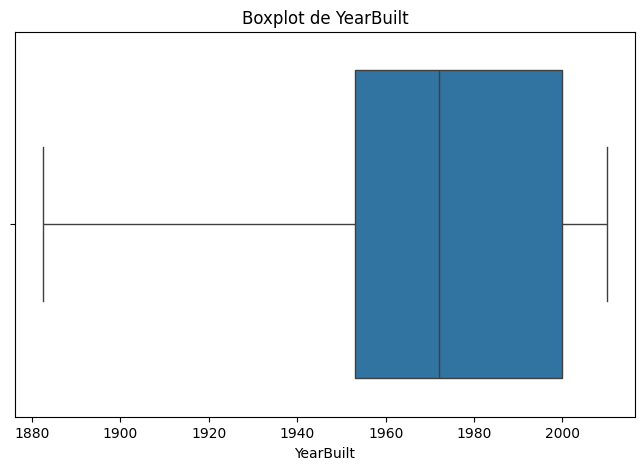

In [421]:
# Vérifions l'effet
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clf["YearBuilt"])
plt.title("Boxplot de YearBuilt")
plt.show()

**Normalisation / Standardisation**

In [422]:
# Standardisation des variables numériques
x_num = x_clf.select_dtypes(exclude='object')

In [423]:
# Standardisation
scaler_clf = StandardScaler()
x_num_scaled = pd.DataFrame(
    scaler_clf .fit_transform(x_clf[num_features]),
    columns=num_features,
    index=x_clf.index
)

In [424]:
# Combiner
x_clf_final = pd.concat([x_num_scaled, x_cat_df], axis=1)
x_clf_final

,GrLivArea,TotRmsAbvGrd,OverallQual,YearBuilt,GarageCars,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,...,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,0.354367,0.898900,0.644778,1.060680,0.309395,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.497580,-0.339142,-0.075501,0.168711,0.309395,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.498893,-0.339142,0.644778,0.994608,0.309395,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.367678,0.279879,0.644778,-1.846476,1.638958,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.282381,1.517920,1.365058,0.961572,1.638958,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,0.234562,0.279879,-0.075501,0.928536,0.309395,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1427,1.044672,0.279879,-0.075501,0.234783,0.309395,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1428,1.552417,1.517920,0.644778,-0.987544,-1.020168,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1429,-0.847487,-0.958163,-0.795780,-0.690221,-1.020168,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**Modélisation :**

**b. Classification :**

SVM

In [455]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(x_clf_final, y_clf_encoded,
                                                    test_size=0.2, random_state=42)

In [426]:
from sklearn import datasets, svm

In [427]:
# Création du modèle support vector machine
svmc = svm.SVC()

In [428]:
# Entrainement
svmc.fit(x_train, y_train)

SVC()

In [429]:
# Prédictions
y_pred_svm = svmc.predict(x_test)

Random Forest

In [456]:
from sklearn.ensemble import RandomForestClassifier

In [431]:
# Paramètres
parameters = {'n_estimators':[4,10,100,25,50,250,15]}

In [457]:
# Modèle
rfc = RandomForestClassifier()
grid = GridSearchCV(rfc, parameters)

In [458]:
# Entrainement
grid.fit(x_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'n_estimators': [4, 10, 100, 25, 50, 250, 15]})

In [459]:
# Vérification avant sauvegarde
print("Type :", type(grid.best_estimator_))
print("Features :", grid.best_estimator_.feature_names_in_.tolist())

# Sauvegarde
with open('model_clf.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)
print("✅ model_clf.pkl sauvegardé !")

Type : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Features : ['GrLivArea', 'TotRmsAbvGrd', 'OverallQual', 'YearBuilt', 'GarageCars', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story', 'HouseStyle_SFoyer', 'HouseStyle_SLvl']
✅ model_clf.pkl sauvegardé !


In [434]:
# meilleure paramètre
grid.best_estimator_

RandomForestClassifier(n_estimators=50)

In [435]:
# Prédictions
y_pred_rfc = grid.best_estimator_.predict(x_test)
y_pred_rfc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 3, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4,
       0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 4, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 0, 0, 0, 4, 0, 0, 4, 0, 0,
       4, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 4,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

**c. Évaluation :**

SVM

In [436]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [437]:
# Accuracy
accuracy_score(y_test, y_pred_svm)

0.8954703832752613

In [438]:
# F1 score
f1_score(y_test, y_pred_svm, average='weighted')

0.8778738764553069

In [439]:
# Matrice de confusion
confusion_matrix(y_test, y_pred_svm)

array([[240,   0,   1,   0,   3],
       [  2,   0,   0,   0,   0],
       [  8,   0,   2,   0,   0],
       [  2,   0,   0,   3,   2],
       [ 11,   0,   0,   1,  12]])

Random forest classifier

In [440]:
# Accuracy
accuracy_score(y_test, y_pred_rfc)

0.9128919860627178

In [441]:
# F1 score
f1_score(y_test, y_pred_rfc, average='weighted')

0.9068231438028266

In [442]:
# Matrice de confusion
confusion_matrix(y_test, y_pred_rfc)

array([[240,   2,   1,   0,   1],
       [  2,   0,   0,   0,   0],
       [  6,   0,   4,   0,   0],
       [  1,   0,   0,   3,   3],
       [  5,   0,   0,   4,  15]])

In [443]:
with open('model_clf.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)  # Random Forest Classification

In [444]:

with open('scaler_clf.pkl', 'wb') as f:
    pickle.dump(scaler_clf, f)

with open('encoder_clf.pkl', 'wb') as f:
    pickle.dump(encoder_clf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)